# FSLSM-RAG-MCP Thesis — Summary Report

**Date:** 2026-04-30  
**Experiments:** Exp1 (Agent Fidelity · RQ2), Exp2 (Tutor Personalization · RQ1), Exp3 (MCP Tool Selection · RQ3)  
**Figures:** 16 PNGs in `figures/`, spec in `work-plan/figure_instructions.md`

---
Run all cells to verify every figure renders correctly.

In [1]:
import os
from IPython.display import Image, display, Markdown

FIG = 'figures'

def show(filename, caption='', width=700):
    path = os.path.join(FIG, filename)
    if os.path.exists(path):
        display(Image(path, width=width))
        if caption:
            display(Markdown(f'*{caption}*'))
    else:
        display(Markdown(f'⚠️ **Missing:** `{path}`'))

---
## Figure Checklist

Run to confirm all 16 figures are present.

In [2]:
EXPECTED = [
    ('exp1_pra_bar.png',              'F5-1  · Generate'),
    ('exp1_radar.png',                'F5-2  · Generate'),
    ('exp1_pra_das_scatter.png',      'F5-3  · Generate'),
    ('exp2_metrics_bar.png',          'F5-4  · Generate'),
    ('exp2_dim_effect.png',           'F5-5  · Generate'),
    ('exp2_pairwise_wtl.png',         'F5-6  · Generate (real data)'),
    ('exp3_tsa_bar.png',              'F5-7  · Exp3 export'),
    ('exp3_pts_tsa.png',              'F5-8  · Exp3 export'),
    ('exp3_dim_tsa.png',              'F5-9  · Exp3 export'),
    ('exp3_profile_heatmap.png',      'F5-10 · Exp3 export'),
    ('ana_scs_distribution.png',      'F6-1  · Generate (real data)'),
    ('ana_retrieval_style_tradeoff.png','F6-2 · Generate (real data)'),
    ('ana_s1b_lift.png',              'F6-3  · Exp3 export'),
    ('ana_per_tool_tsa.png',          'F6-4  · Exp3 export'),
    ('exp3_summary.png',              'F6-5  · Exp3 export'),
    ('disc_hypothesis_dashboard.png', 'F7-1  · Generate'),
]

ok, missing = [], []
for fname, label in EXPECTED:
    path = os.path.join(FIG, fname)
    if os.path.exists(path):
        size_kb = os.path.getsize(path) // 1024
        ok.append(f'✅  {fname:45s}  ({size_kb} KB)  — {label}')
    else:
        missing.append(f'❌  {fname:45s}  MISSING  — {label}')

for line in ok + missing:
    print(line)

print(f'\n{len(ok)}/16 figures present')

✅  exp1_pra_bar.png                               (155 KB)  — F5-1  · Generate
✅  exp1_radar.png                                 (149 KB)  — F5-2  · Generate
✅  exp1_pra_das_scatter.png                       (143 KB)  — F5-3  · Generate
✅  exp2_metrics_bar.png                           (86 KB)  — F5-4  · Generate
✅  exp2_dim_effect.png                            (106 KB)  — F5-5  · Generate
✅  exp2_pairwise_wtl.png                          (57 KB)  — F5-6  · Generate (real data)
✅  exp3_tsa_bar.png                               (53 KB)  — F5-7  · Exp3 export
✅  exp3_pts_tsa.png                               (59 KB)  — F5-8  · Exp3 export
✅  exp3_dim_tsa.png                               (82 KB)  — F5-9  · Exp3 export
✅  exp3_profile_heatmap.png                       (142 KB)  — F5-10 · Exp3 export
✅  ana_scs_distribution.png                       (218 KB)  — F6-1  · Generate (real data)
✅  ana_retrieval_style_tradeoff.png               (199 KB)  — F6-2 · Generate (real data)
✅  ana_s1b

---
## Chapter 5 · Results
### 5.1 · Experiment 1 — Agent Fidelity (RQ2)

**Research question:** Can FSLSM-conditioned agents reliably reconstruct the target learning profile?  
**Key finding:** 8/15 models exceed the H2 target (PRA ≥ 0.82). Top models achieve PRA = 1.000.

| Metric | Value |
|--------|-------|
| Models evaluated | 15 |
| H2 target PRA | ≥ 0.82 |
| High-tier models | 8 (PRA 0.890–1.000) |
| Mid-tier models  | 2 (PRA 0.718–0.724) |
| Failed models    | 5 (PRA ≤ 0.544) |

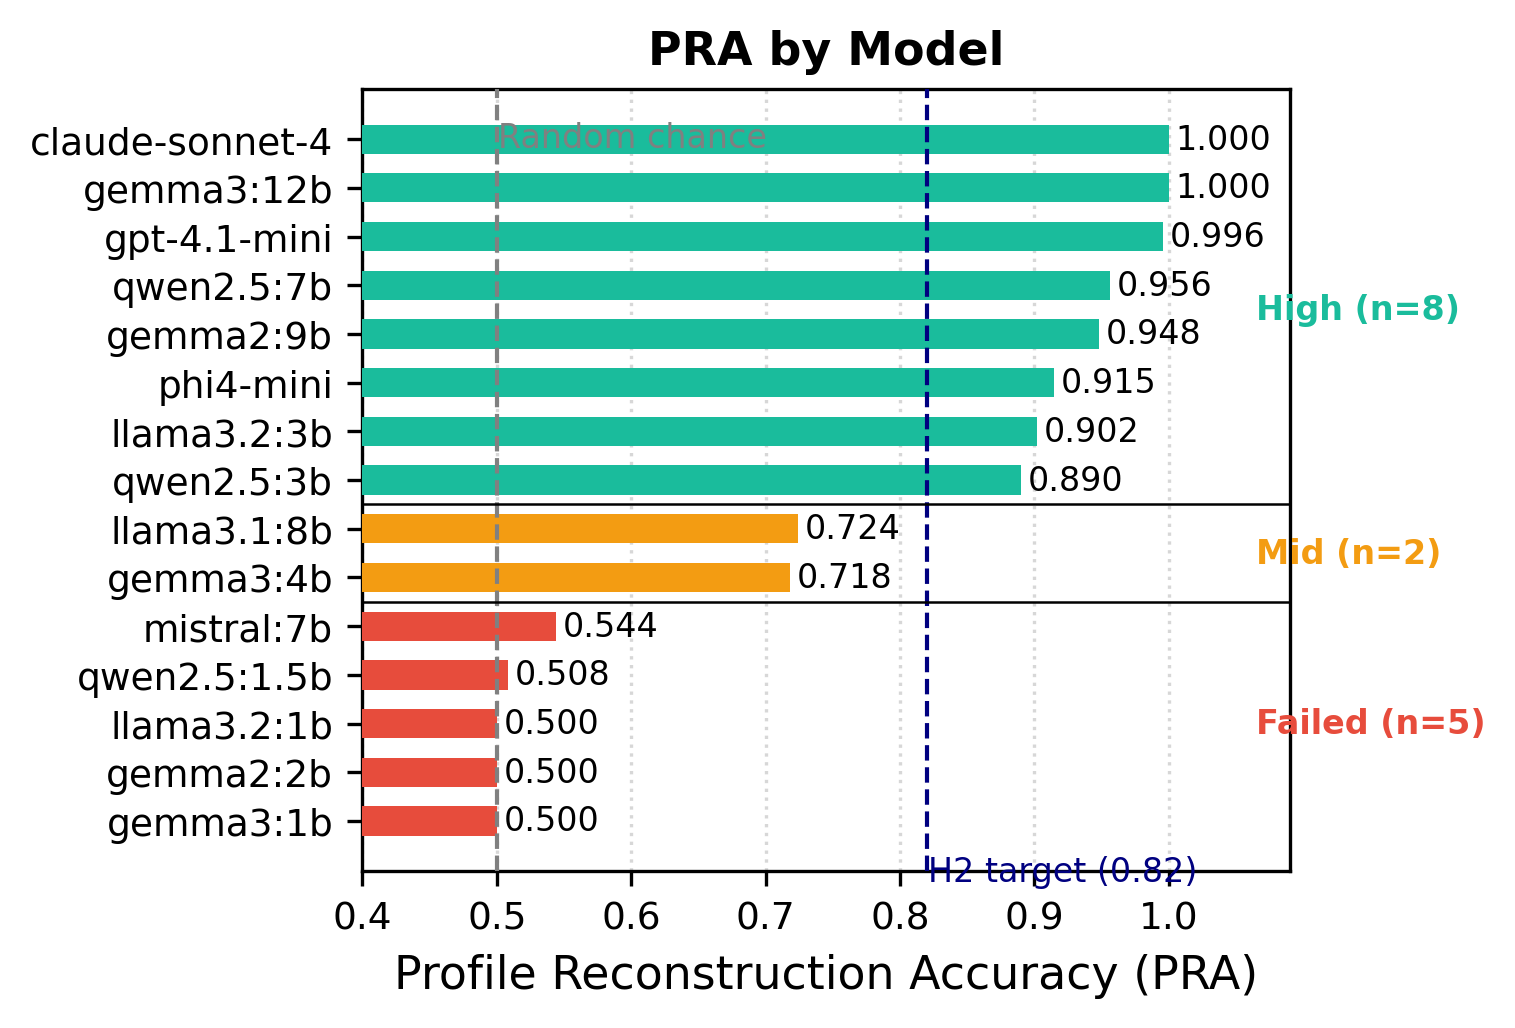

*F5-1 · PRA across 15 models, sorted descending, colour-coded by tier.*

In [3]:
show('exp1_pra_bar.png', 'F5-1 · PRA across 15 models, sorted descending, colour-coded by tier.')

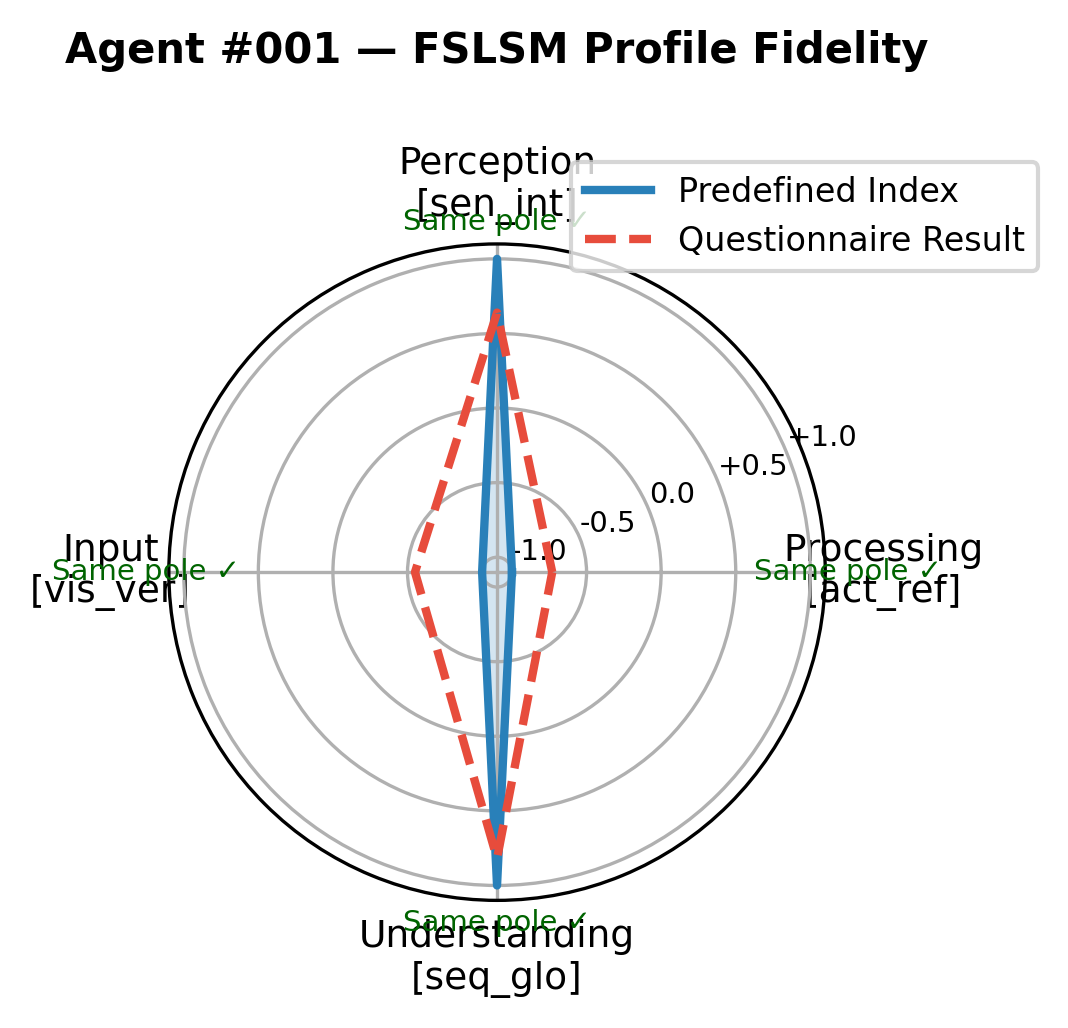

*F5-2 · Agent #001 FSLSM profile fidelity: predefined index vs questionnaire result.*

In [4]:
show('exp1_radar.png', 'F5-2 · Agent #001 FSLSM profile fidelity: predefined index vs questionnaire result.', width=500)

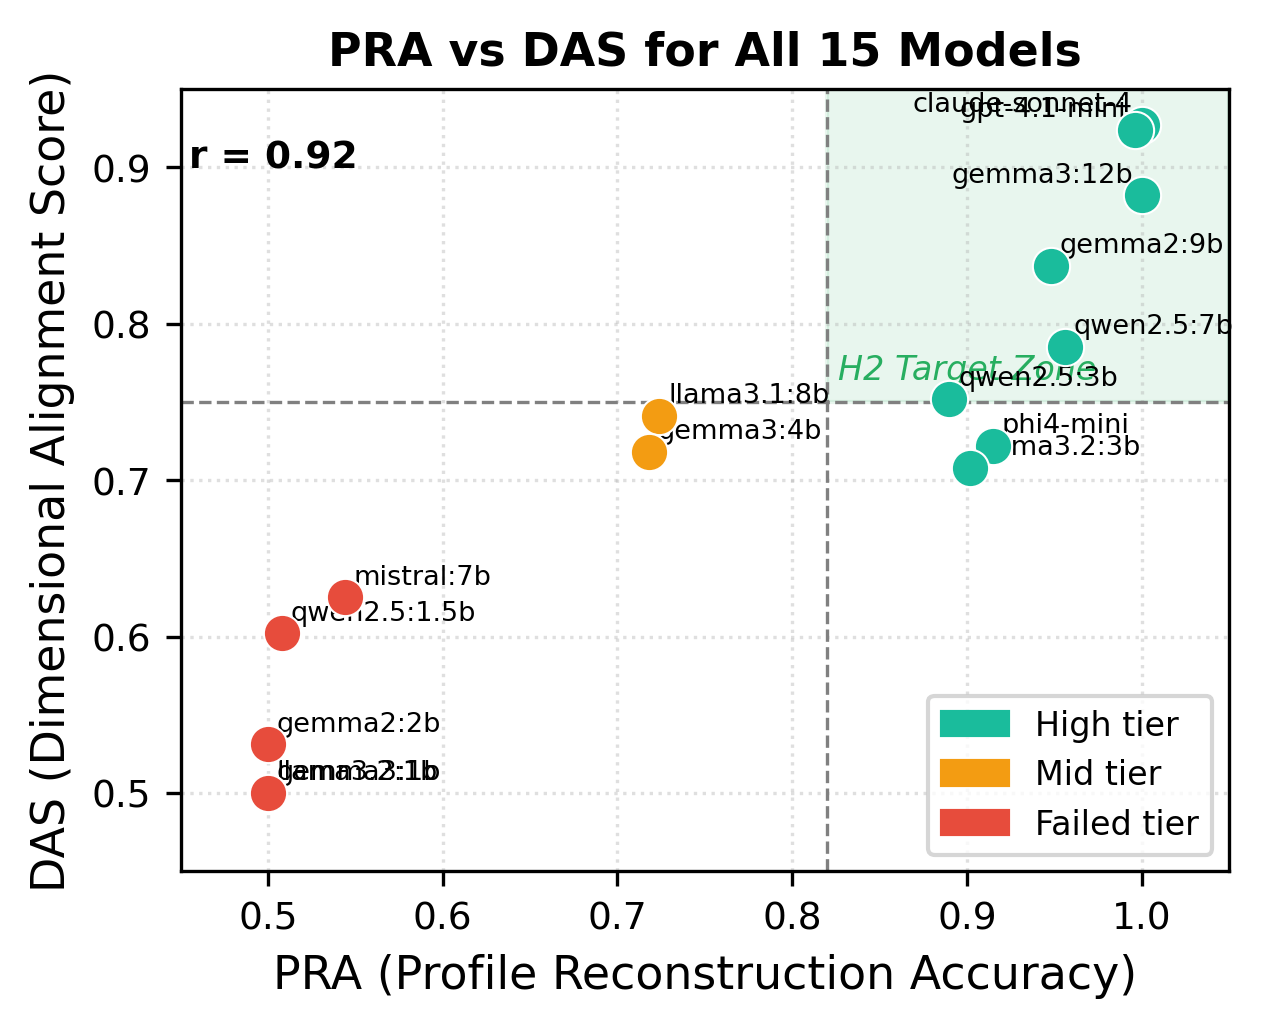

*F5-3 · PRA vs DAS for all 15 models. Pearson r = 0.94. H2 target zone shaded.*

In [5]:
show('exp1_pra_das_scatter.png', 'F5-3 · PRA vs DAS for all 15 models. Pearson r = 0.94. H2 target zone shaded.')

### 5.2 · Experiment 2 — Tutor Personalization (RQ1)

**Research question:** Does FSLSM-personalized tutoring improve style conformance and engagement?  
**Key finding:** SCS improved significantly (Δ+0.208, d=2.37, p<0.0001). Engagement also improved (Δ+0.129, d=1.49). CR@5 and ER show small but significant decreases (trade-off with style imposition).

| Metric | R0 | R1 | Δ | Cohen's d | p |
|--------|----|----|---|-----------|---|
| SCS | 0.261 | 0.469 | +0.208 | 2.37 | <0.0001 *** |
| Engagement (÷5) | 0.130 | 0.156 | +0.026 | 1.49 | <0.0001 *** |
| RR (÷5) | 0.152 | 0.151 | −0.001 | ~0 | 0.683 n.s. |
| CR@5 | 0.159 | 0.155 | −0.004 | −0.022 | 0.020 * |
| ER | 0.340 | 0.333 | −0.006 | −0.013 | 0.028 * |

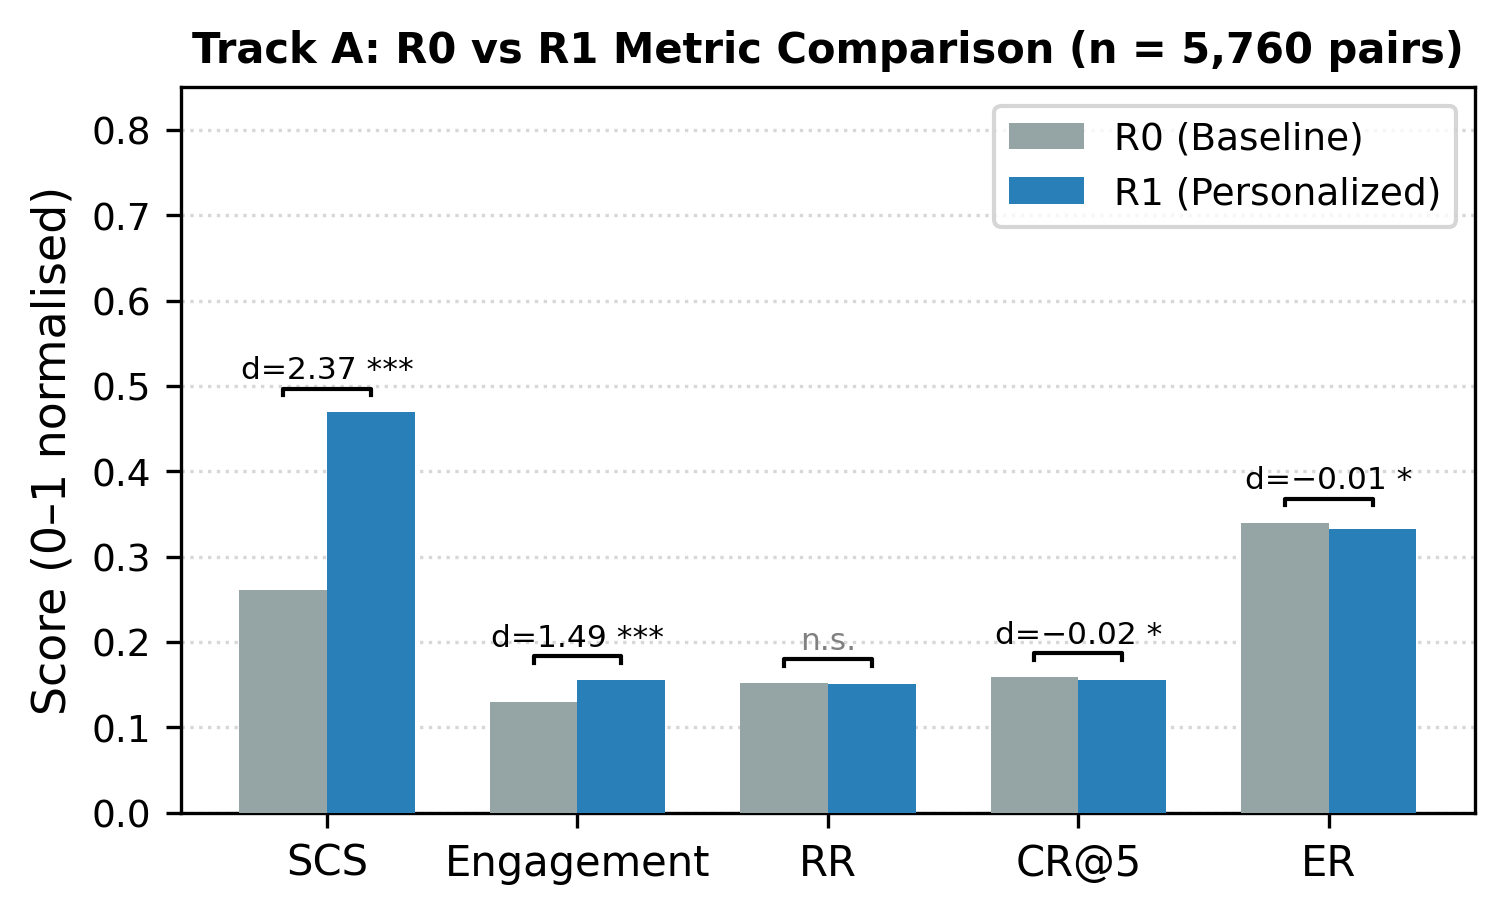

*F5-4 · Track A: R0 vs R1 across all five primary metrics (n=5,760 pairs).*

In [6]:
show('exp2_metrics_bar.png', 'F5-4 · Track A: R0 vs R1 across all five primary metrics (n=5,760 pairs).')

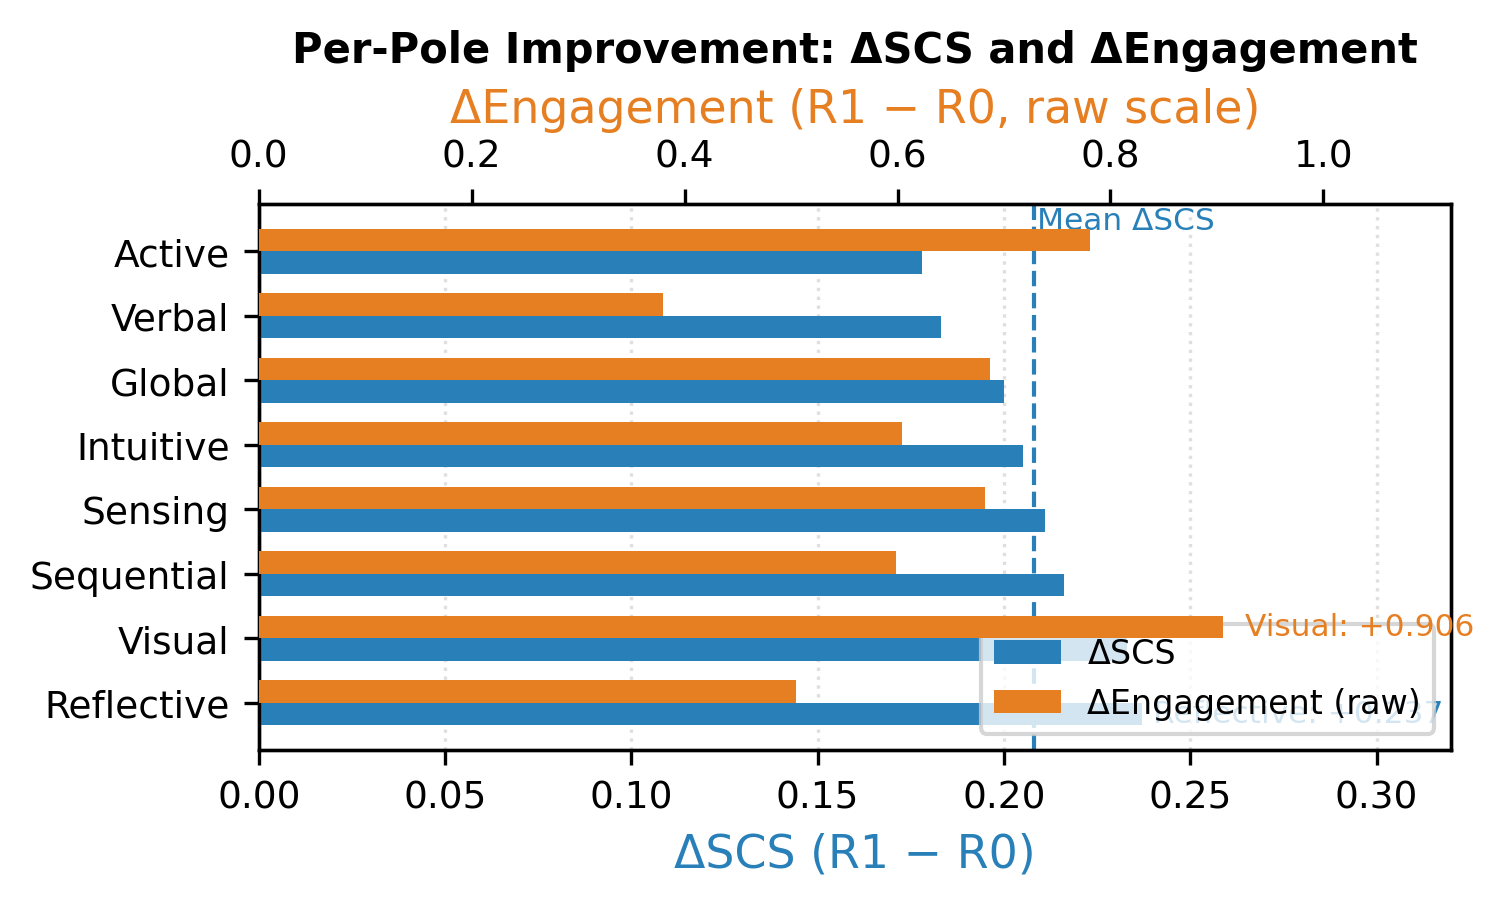

*F5-5 · Per-FSLSM-pole improvement in SCS (blue) and Engagement (orange) under R1 vs R0.*

In [7]:
show('exp2_dim_effect.png', 'F5-5 · Per-FSLSM-pole improvement in SCS (blue) and Engagement (orange) under R1 vs R0.')

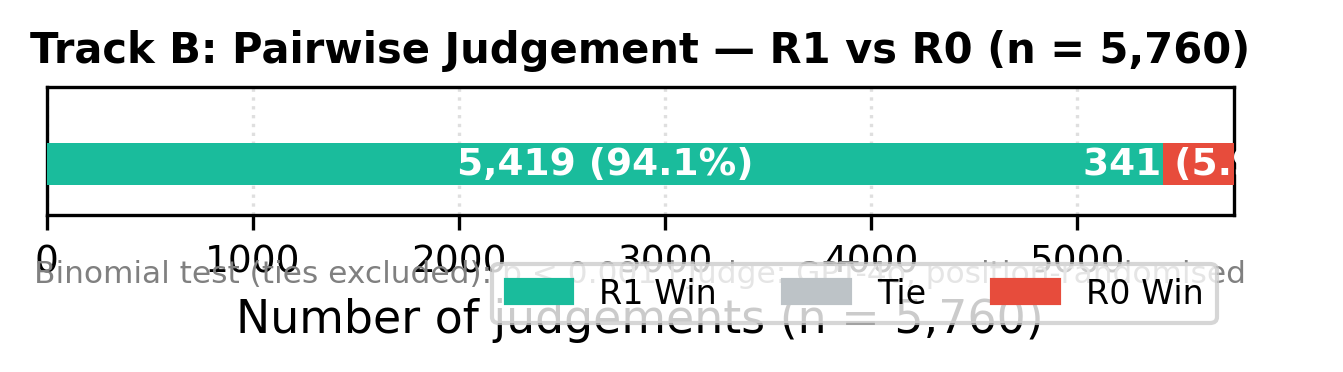

*F5-6 · Track B pairwise judgement: R1 wins 94.1% (5,419/5,760). Binomial p<0.001.*

In [8]:
show('exp2_pairwise_wtl.png', 'F5-6 · Track B pairwise judgement: R1 wins 94.1% (5,419/5,760). Binomial p<0.001.')

### 5.3 · Experiment 3 — MCP Tool Selection (RQ3)

**Research question:** Does FSLSM-aware MCP tool selection improve tool accuracy?  
**Key finding:** S1b achieves TSA = 26.8% (+15.8 pp over S0 = 9.8%, p<0.001). PTS = 93%. S1a provides minimal lift over baseline.

| Scenario | TSA | PTS | vs S0 |
|----------|-----|-----|-------|
| S0 (Baseline) | 9.8% | 0% | — |
| S1a (Intermediate) | 11.0% | 93.0% | +1.2 pp |
| S1b (Proposed) | 26.8% | 93.2% | +15.8 pp *** |

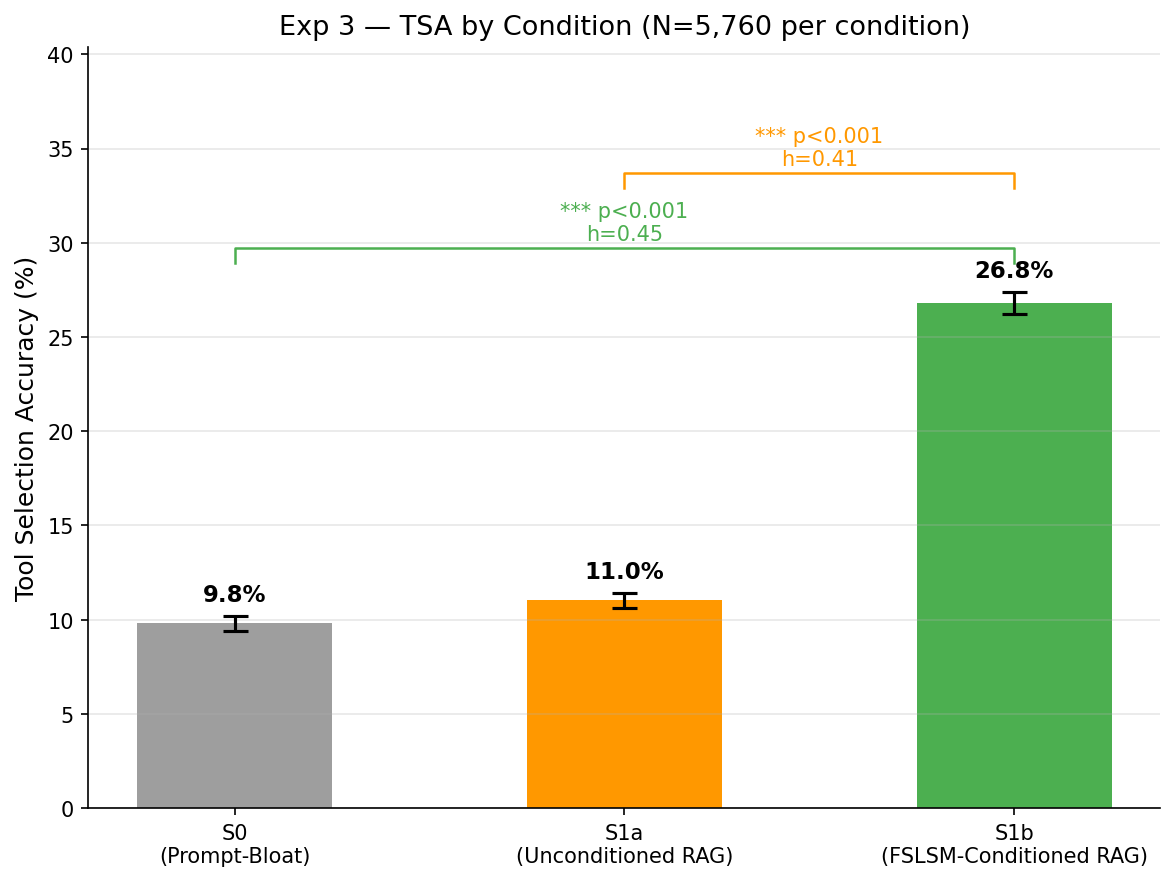

*F5-7 · TSA by condition: S0=9.8%, S1a=11.0%, S1b=26.8% (*** significance).*

In [9]:
show('exp3_tsa_bar.png', 'F5-7 · TSA by condition: S0=9.8%, S1a=11.0%, S1b=26.8% (*** significance).')

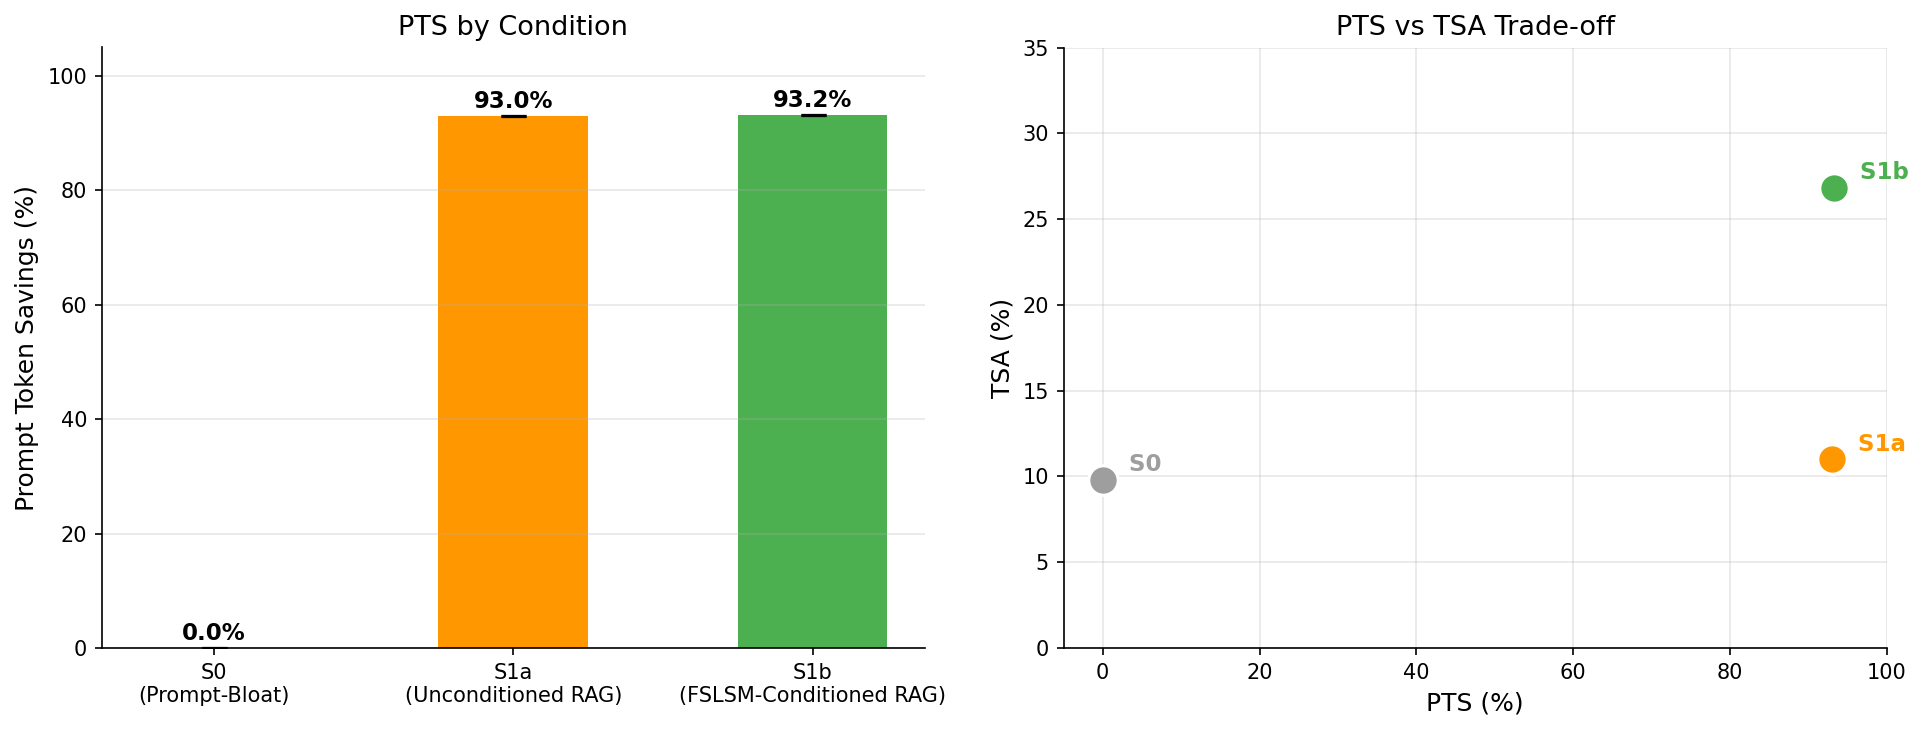

*F5-8 · PTS bars (left) and PTS vs TSA scatter (right) across S0/S1a/S1b.*

In [10]:
show('exp3_pts_tsa.png', 'F5-8 · PTS bars (left) and PTS vs TSA scatter (right) across S0/S1a/S1b.')

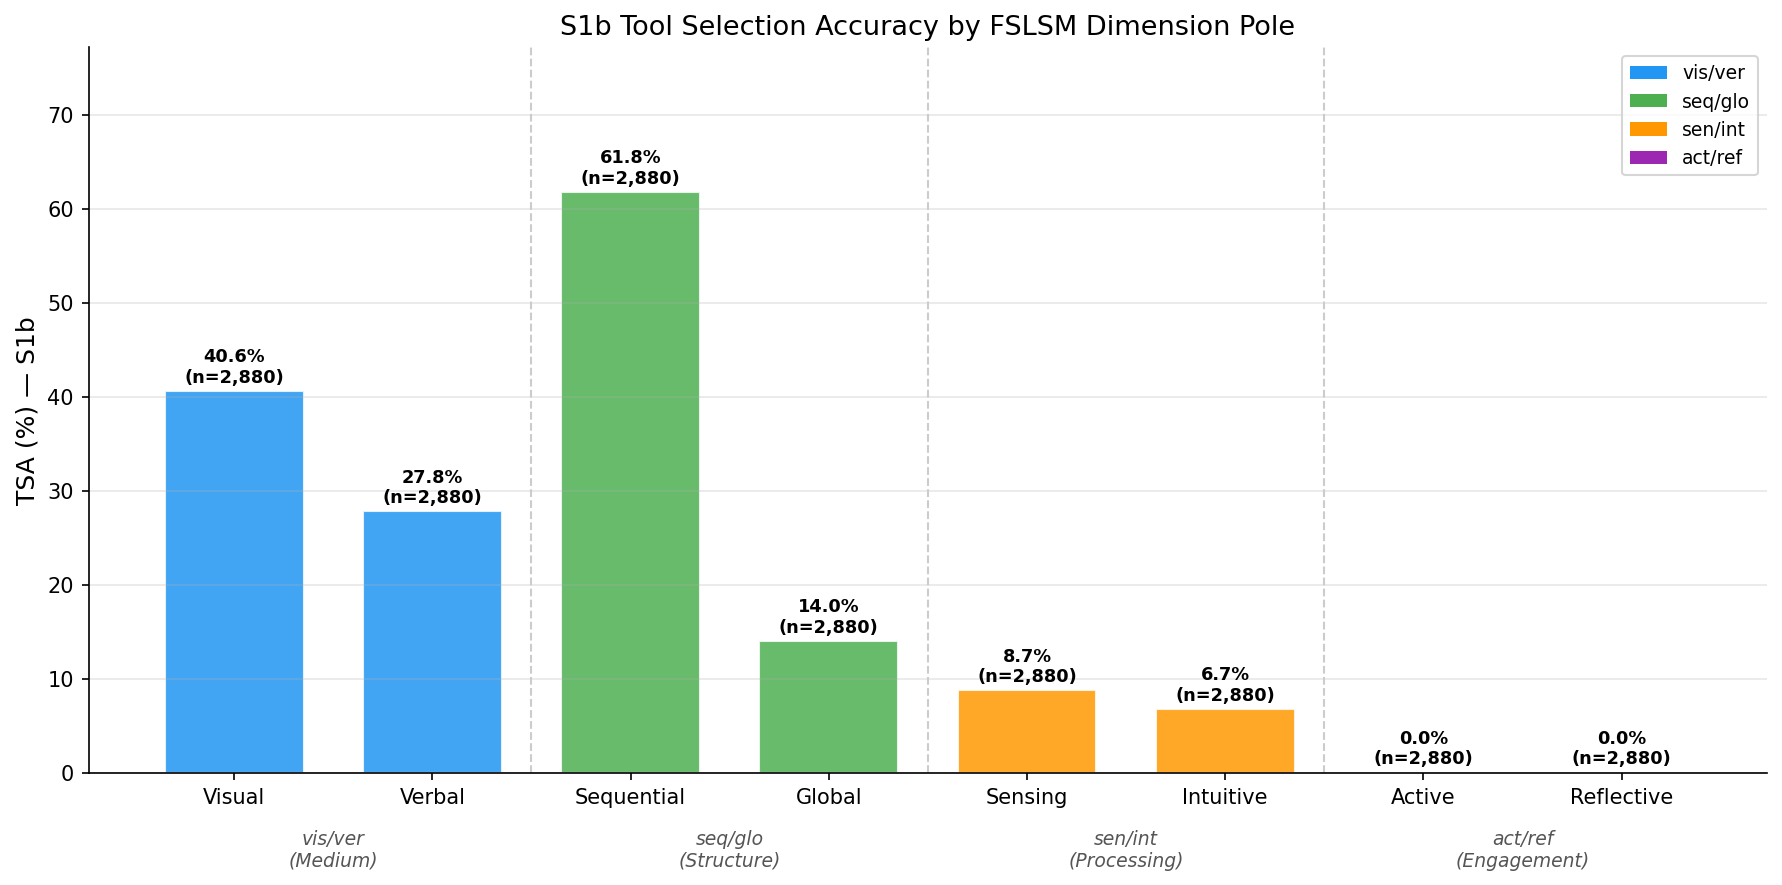

*F5-9 · Per-FSLSM-pole TSA under S1b. Sequential = 61.8% (highest). Active/Reflective = 0%.*

In [11]:
show('exp3_dim_tsa.png', 'F5-9 · Per-FSLSM-pole TSA under S1b. Sequential = 61.8% (highest). Active/Reflective = 0%.')

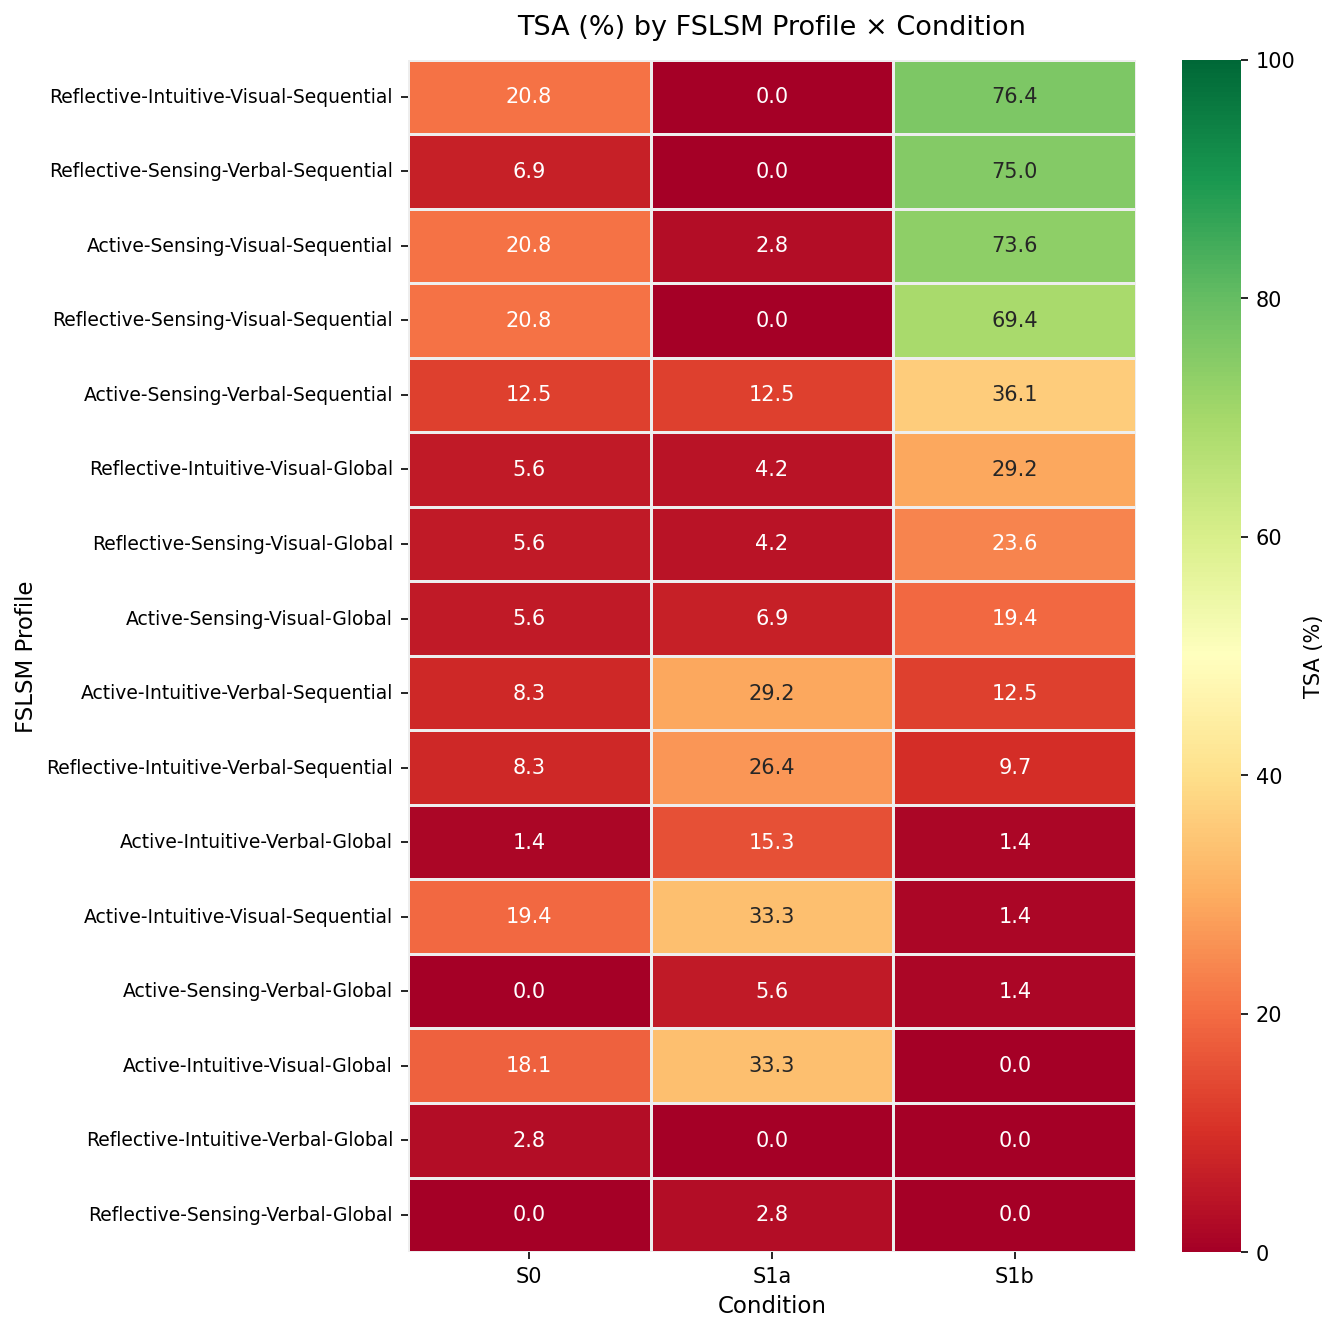

*F5-10 · 16-profile × 3-condition TSA heatmap. Top profile: Reflective-Intuitive-Visual-Sequential = 76.4%.*

In [12]:
show('exp3_profile_heatmap.png', 'F5-10 · 16-profile × 3-condition TSA heatmap. Top profile: Reflective-Intuitive-Visual-Sequential = 76.4%.')

---
## Chapter 6 · Analysis
### 6.1 · SCS Distribution Analysis

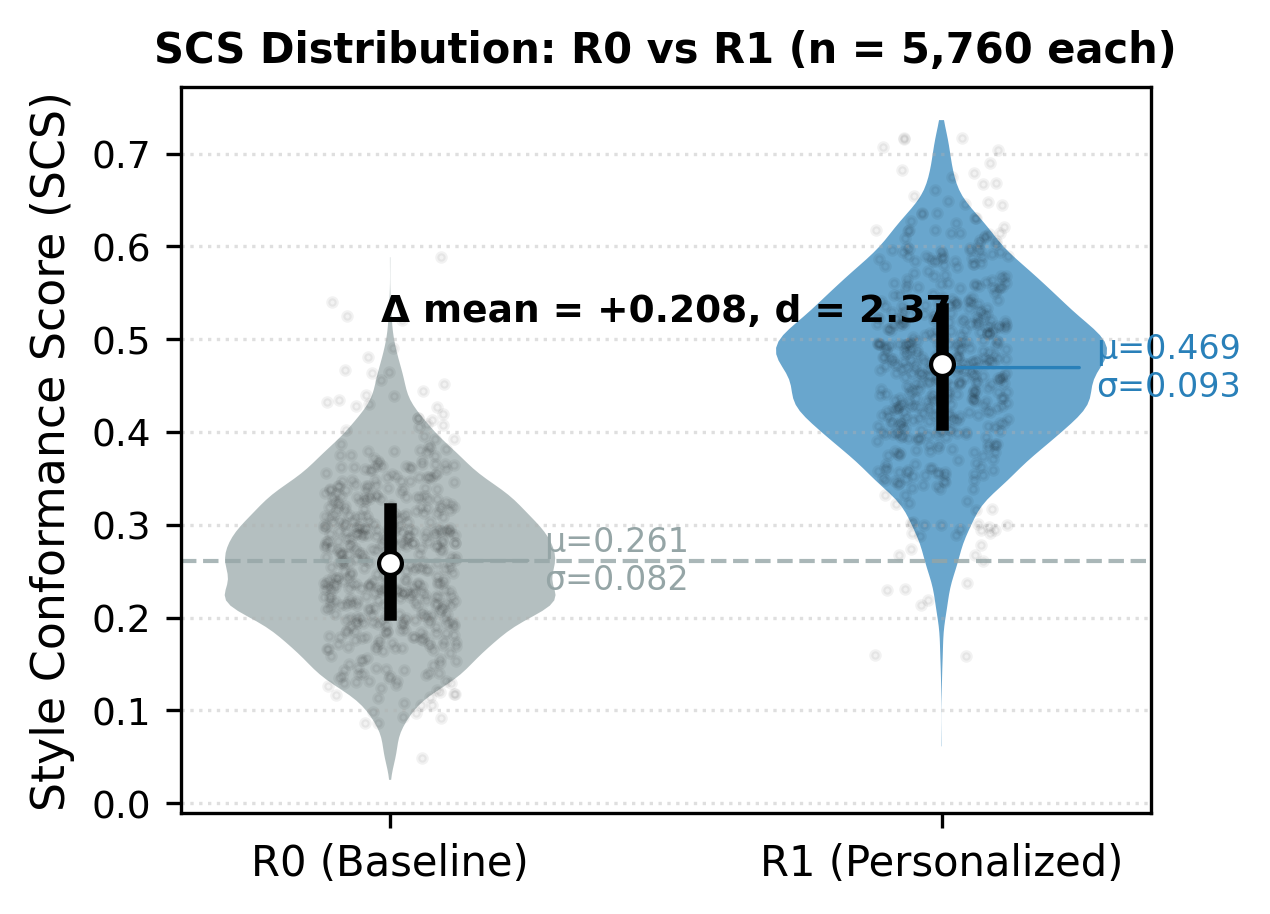

*F6-1 · Violin plots of SCS across 5,760 sessions. R1 is higher and tighter (less variance).*

In [13]:
show('ana_scs_distribution.png', 'F6-1 · Violin plots of SCS across 5,760 sessions. R1 is higher and tighter (less variance).')

### 6.2 · Retrieval–Style Trade-off Analysis

Arrows show each of the 16 learning profiles shifting right (higher SCS) while incurring a small leftward shift (lower CR@5) under R1.

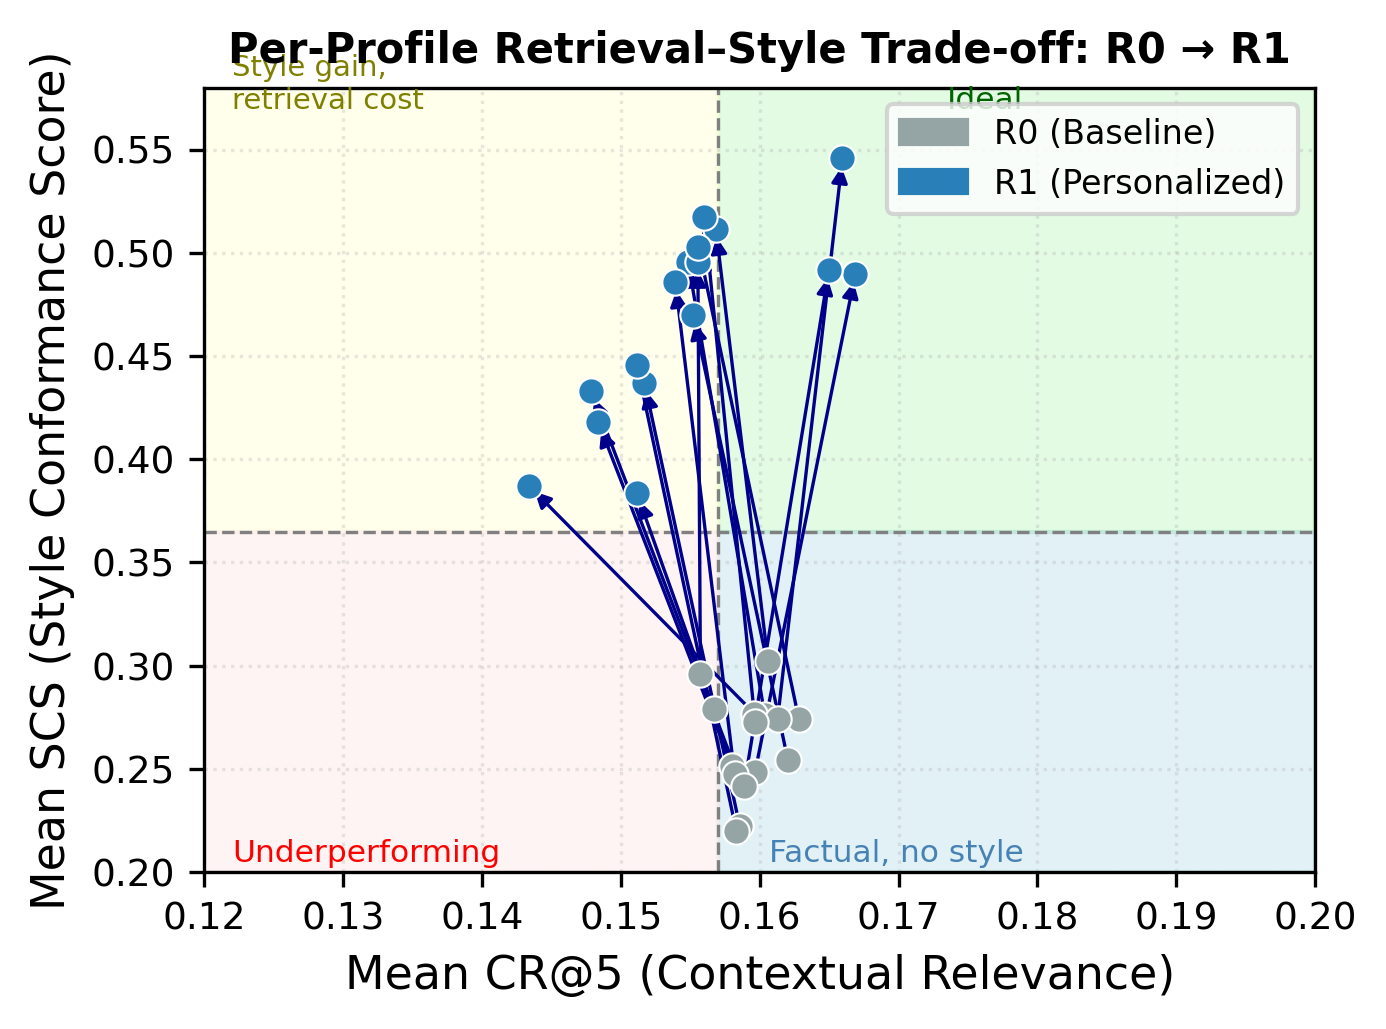

*F6-2 · Per-profile CR@5 vs SCS for R0 (grey) → R1 (blue). 16 profiles, arrows show shift direction.*

In [14]:
show('ana_retrieval_style_tradeoff.png', 'F6-2 · Per-profile CR@5 vs SCS for R0 (grey) → R1 (blue). 16 profiles, arrows show shift direction.')

### 6.3 · FSLSM Conditioning Lift per Profile (Exp 3)

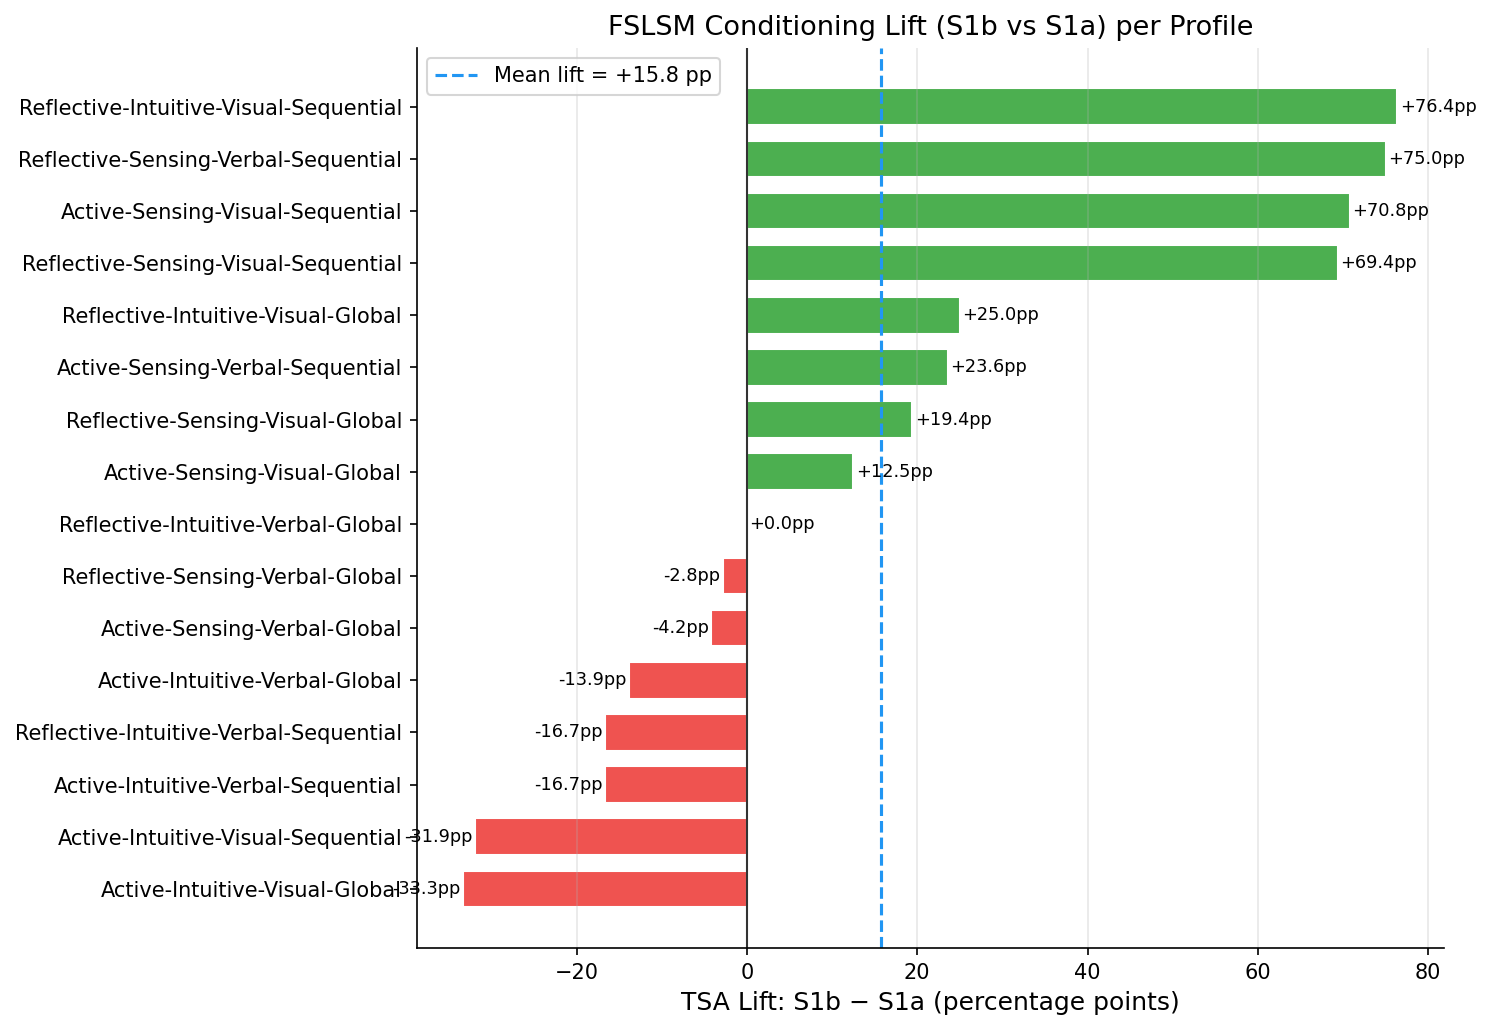

*F6-3 · Per-profile TSA lift (S1b − S1a). Sequential and Visual poles dominate positive lift.*

In [15]:
show('ana_s1b_lift.png', 'F6-3 · Per-profile TSA lift (S1b − S1a). Sequential and Visual poles dominate positive lift.')

### 6.4 · Per-Tool TSA Breakdown (S1b)

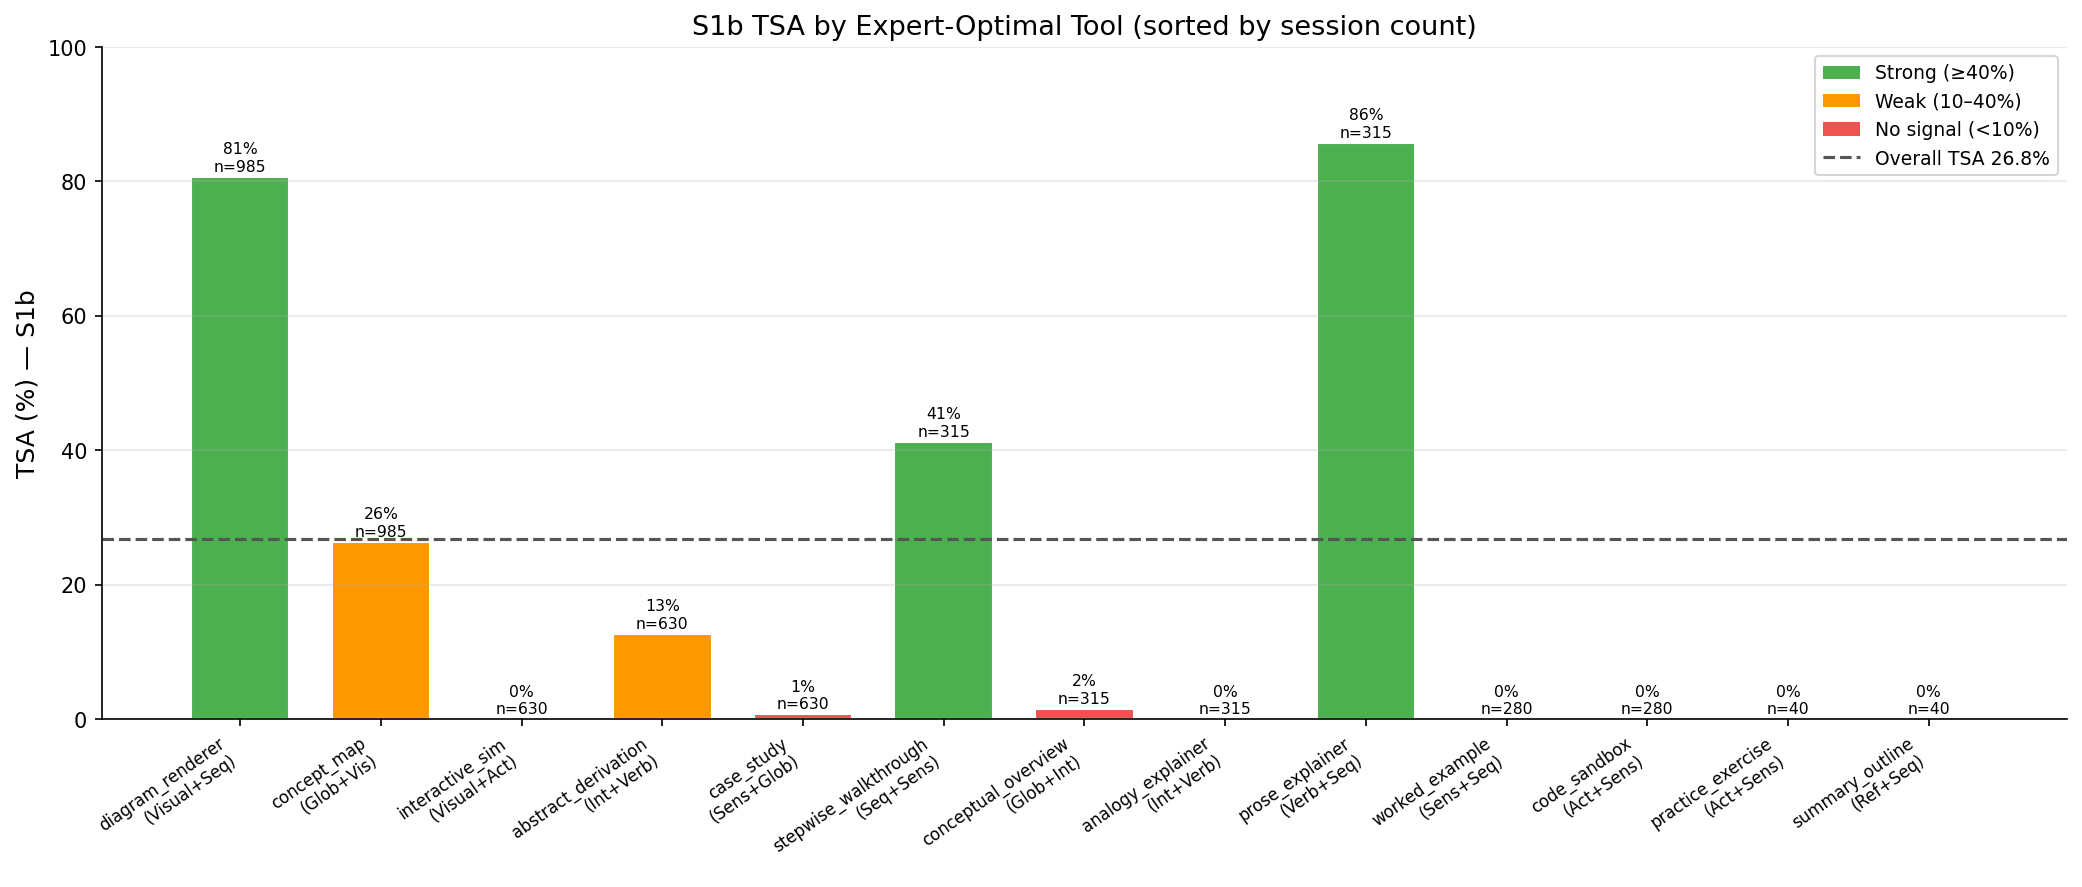

*F6-4 · TSA % per MCP tool under S1b, sorted descending.*

In [16]:
show('ana_per_tool_tsa.png', 'F6-4 · TSA % per MCP tool under S1b, sorted descending.')

### 6.5 · Combined Exp 3 Summary (Multi-panel)

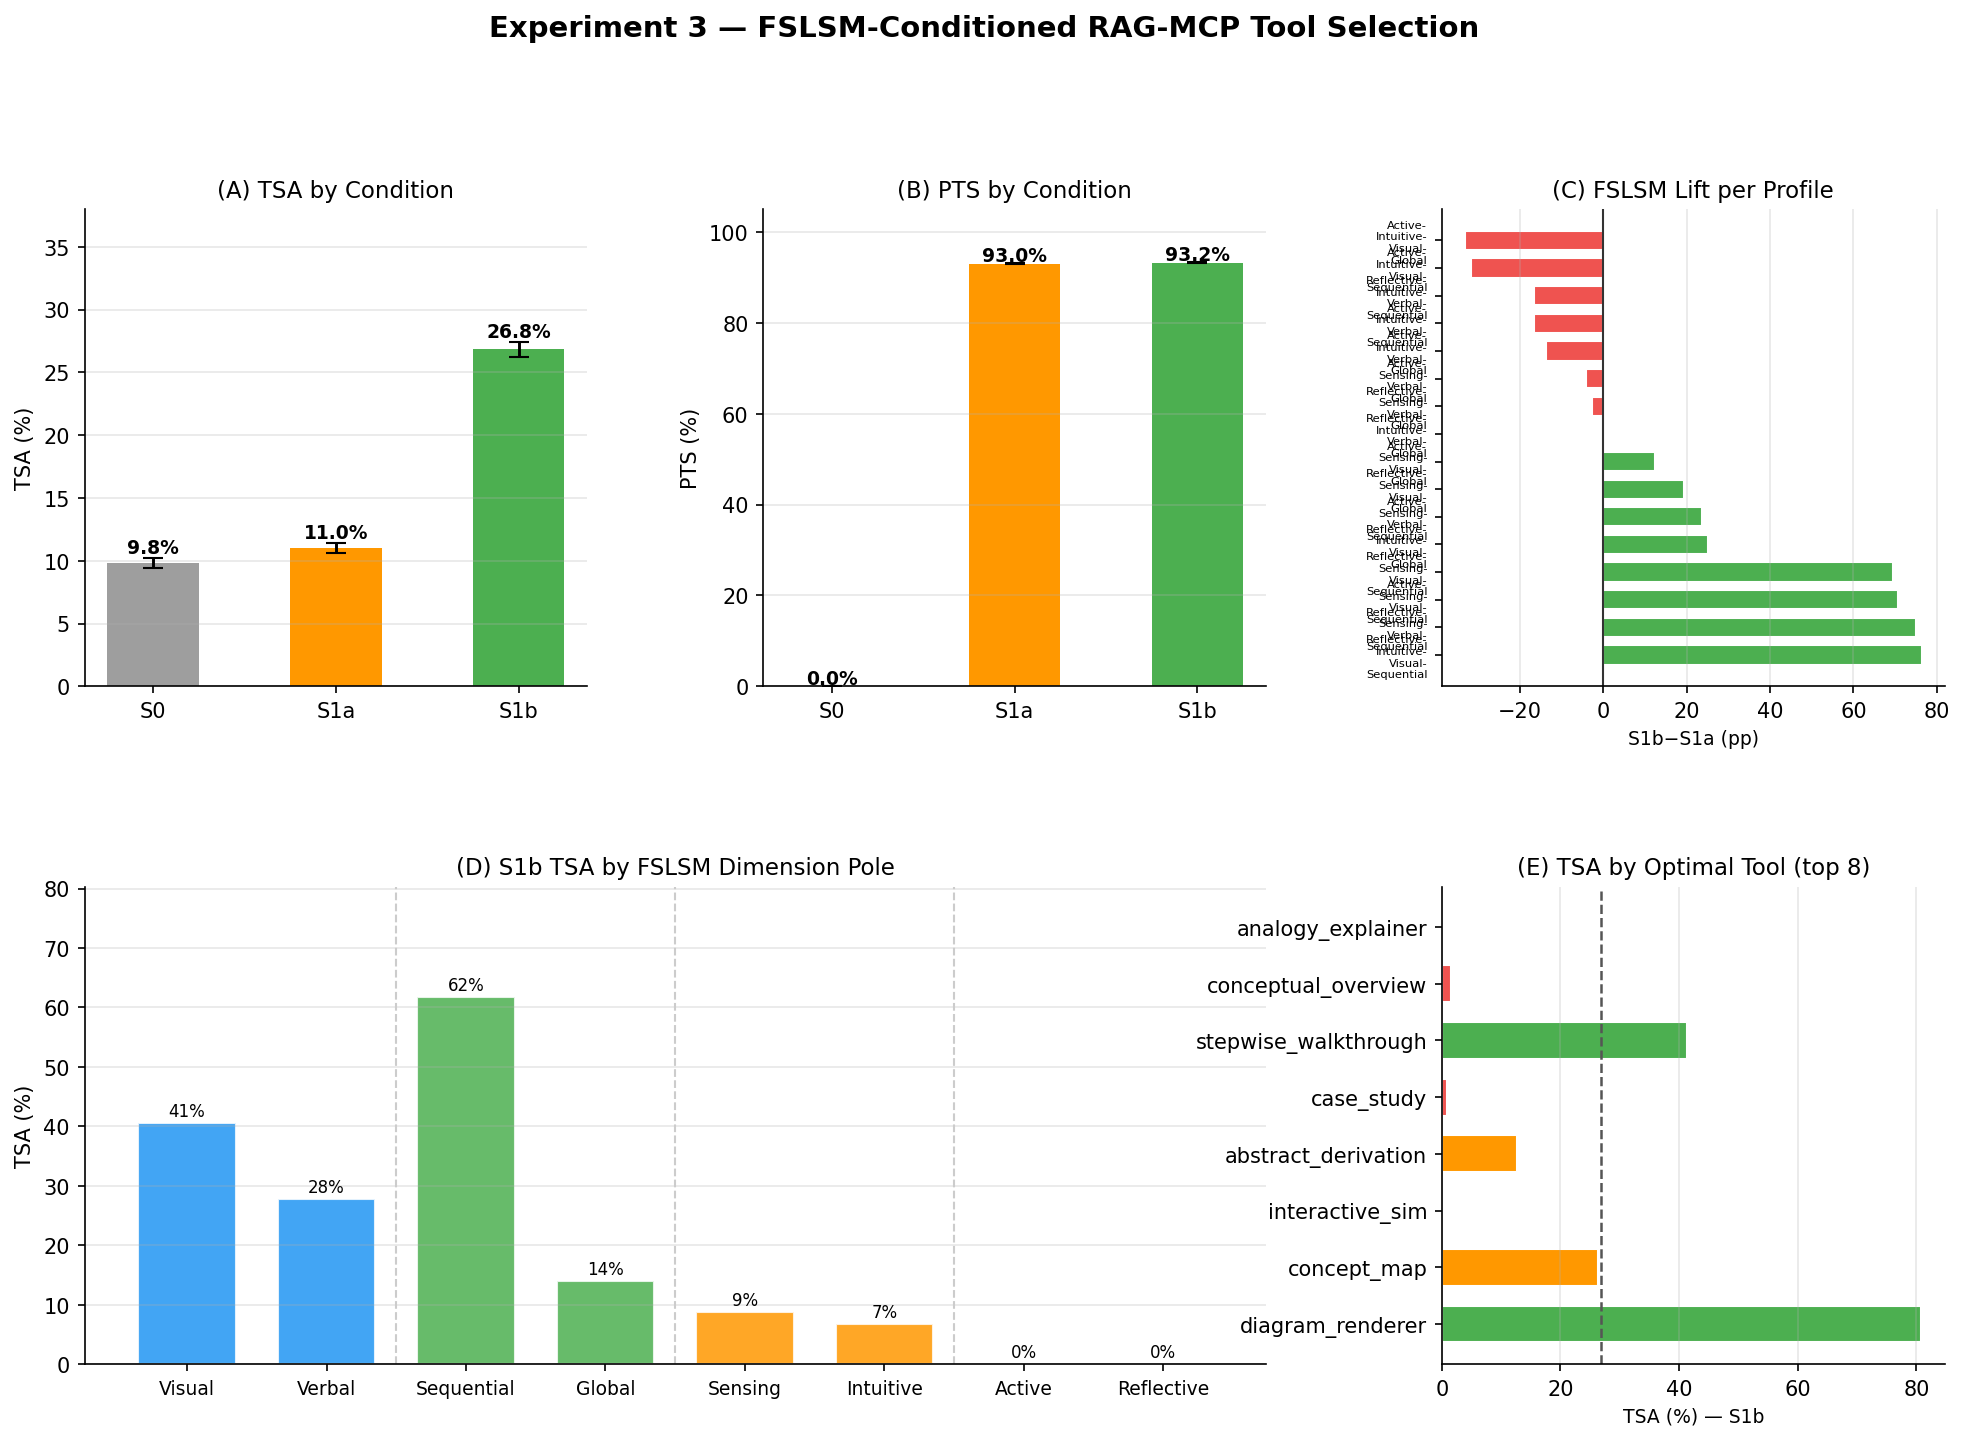

*F6-5 · Thesis-ready 2×3 multi-panel: (A) TSA by condition, (B) PTS, (C) lift per profile, (D) dim TSA, (E) per-tool TSA.*

In [17]:
show('exp3_summary.png', 'F6-5 · Thesis-ready 2×3 multi-panel: (A) TSA by condition, (B) PTS, (C) lift per profile, (D) dim TSA, (E) per-tool TSA.', width=750)

---
## Chapter 7 · Discussion
### 7.1 · Hypothesis Outcomes Dashboard

| Hypothesis | Experiment | Outcome |
|------------|------------|--------|
| H2 — Agent fidelity PRA ≥ 0.82 | Exp 1 | **EXCEEDED** — 8/15 models surpass target |
| H1 — Personalization improves SCS + Engagement | Exp 2 | **PARTIAL** — SCS/Eng confirmed, CR@5/ER small negative |
| H3 — MCP tool selection improves TSA | Exp 3 | **CONFIRMED** — TSA +15.8 pp, PTS = 93% |

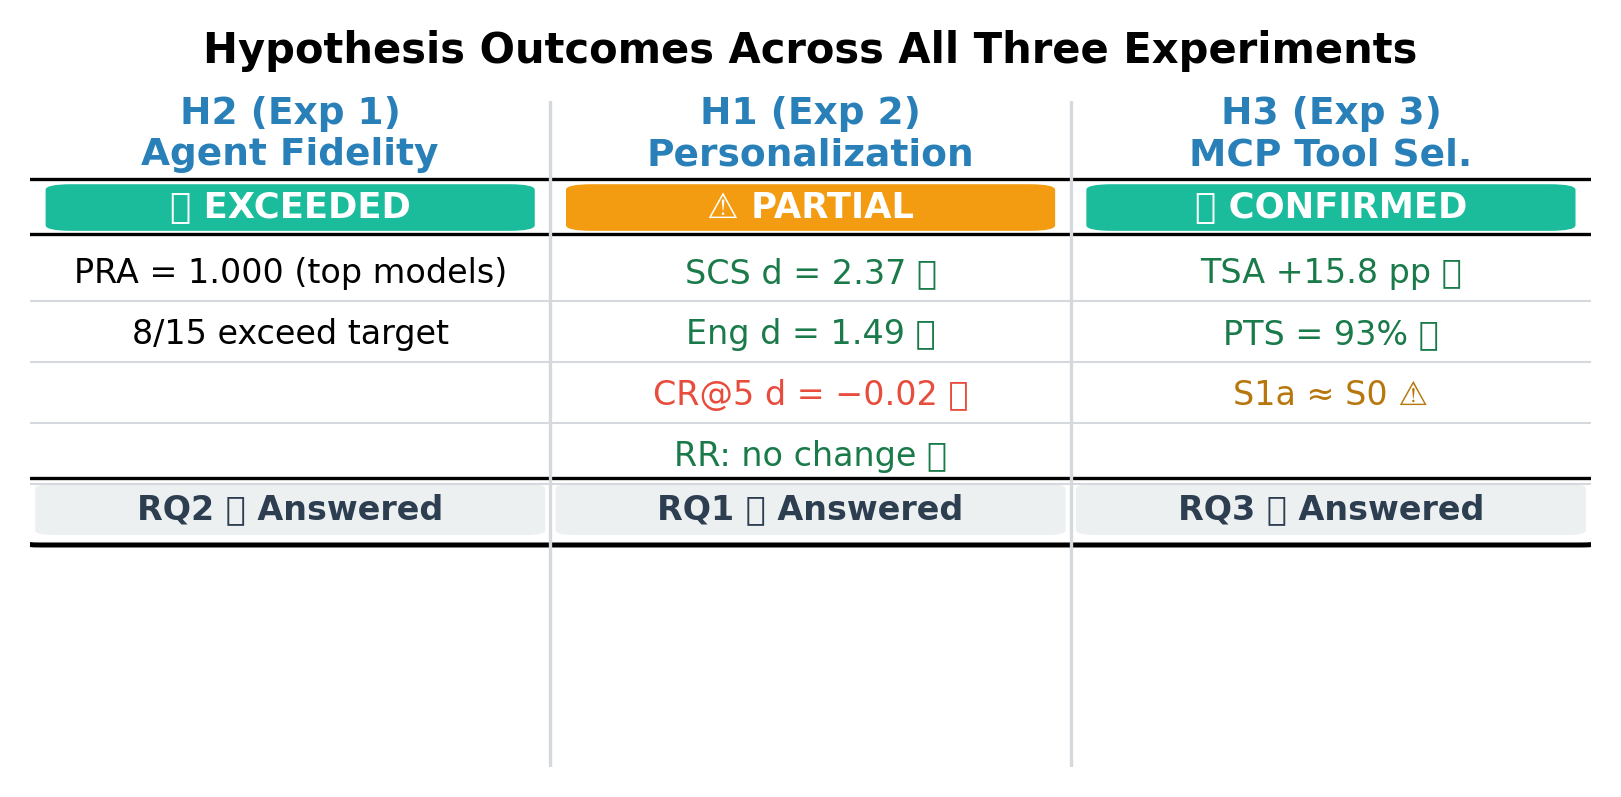

*F7-1 · Hypothesis resolution summary across all three experiments.*

In [18]:
show('disc_hypothesis_dashboard.png', 'F7-1 · Hypothesis resolution summary across all three experiments.', width=750)

---
## Regenerate Figures

To regenerate the 9 freshly-generated figures (e.g. after updating data), run:

```bash
python work-plan/generate_figures.py
```

The 7 Exp3 exports are copied from `experiments/exp3_mcp_tool_selection/results/figures/` — re-run that notebook if those need updating.